# Desarrollo de modelos

En esta seccion se desarrollaran los modelos de prediccion para la investigacion. Al tener un problema de clasificacion, se trabajaran los siguientes modelos adicionales al modelo original. Estos modelos de clasificacion son los siguientes: 

 - KNN → KD-Trees, Ball Trees, FAISS.
 - Naive Bayes → partial_fit() para entrenamiento por lotes.
 - XGBoost → tree_method='hist' y early_stopping_rounds.
 - SVM → SGD SVM (SGDClassifier) , LinearSVC en vez de SVC(kernel='linear'), RBF con Random Fourier Features

En las siguientes lineas de codigo, se encontrara el desarrollo de los modelos.

In [20]:
import pandas as pd
df = pd.read_csv("metricas_camiones.csv")

Cargamos los datos Pre-procesados para el desarrollo de los modelos.

### Modelo KNN

En las siguientes lineas de codigos, aplicaremos los modelos KD-Trees, Ball Trees Y FAISS.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE

In [34]:
# Definir variables predictoras y objetivo
X = df.drop(columns=["Equipo", "Suspension", "Falla"])  # Ajusta según tus datos
y = df["Falla"]

# Crear pipeline con escalado y clasificador KNN
pipe = make_pipeline(StandardScaler(), KNeighborsClassifier())

# Definir hiperparámetros para GridSearch
param_grid = {
    "kneighborsclassifier__n_neighbors": [3, 5, 7, 9, 10],
    "kneighborsclassifier__weights": ["distance"],
    "kneighborsclassifier__metric": ["euclidean"],
    "kneighborsclassifier__algorithm": ["ball_tree", "kd_tree"]
}

# Definir Nested Cross-Validation (Validación externa e interna)
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Variables para guardar resultados
all_y_true = []
all_y_pred = []
nested_scores = []

# Iterar sobre los folds de la validación externa
for train_idx, test_idx in cv_outer.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Aplicar SMOTE a los datos de entrenamiento
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Aplicar GridSearchCV dentro de cada fold con los datos balanceados
    grid_search = GridSearchCV(pipe, param_grid, cv=cv_inner, scoring="accuracy", n_jobs=1)
    grid_search.fit(X_train_res, y_train_res)  # Usamos los datos balanceados para entrenar

    # Obtener el mejor modelo y hacer predicciones en los datos de prueba
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # Guardar resultados
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    nested_scores.append(grid_search.best_score_)

En el codigo anterior podemos observar como se realizo el modelo KNN mediante el uso de paramgrid, Gridsearch y un pipeline. La validacion aplicada fue Nested Cross-Validation. 

En el siguiente codigo aplicamos SMOTE a los datos de entrenamiento

In [37]:
# Verificar distribución antes de SMOTE
print("Distribución antes de SMOTE:")
print(y_train.value_counts())

# Verificar distribución después de SMOTE
print("\nDistribución después de SMOTE:")
print(y_train_res.value_counts())

Distribución antes de SMOTE:
1    10
0     7
Name: Falla, dtype: int64

Distribución después de SMOTE:
0    10
1    10
Name: Falla, dtype: int64


Nested CV Scores:  [0.7777777777777778, 0.7222222222222222, 0.6507936507936507, 0.8015873015873015, 0.8492063492063492]
Mean Accuracy: 0.7603 ± 0.0683


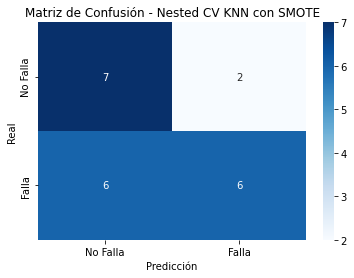

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.54      0.78      0.64         9
           1       0.75      0.50      0.60        12

    accuracy                           0.62        21
   macro avg       0.64      0.64      0.62        21
weighted avg       0.66      0.62      0.62        21



In [36]:
# Mostrar resultados de Nested Cross-Validation
print("Nested CV Scores: ", nested_scores)
print("Mean Accuracy: {:.4f} ± {:.4f}".format(np.mean(nested_scores), np.std(nested_scores)))

# Matriz de Confusión
conf_matrix = confusion_matrix(all_y_true, all_y_pred)

# Visualizar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Falla", "Falla"], yticklabels=["No Falla", "Falla"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Nested CV KNN con SMOTE")
plt.show()

# Métricas adicionales
print("Reporte de clasificación:\n", classification_report(all_y_true, all_y_pred))

### Modelo L1/L2 Penalty Logistic Regression 

### Modelo Random Forest 

### Modelo XGBoost

### Modelo SVM (Support Vector Machines)

### Modelo ANN (Redes Neuronales Artificiales)

### Resultados 